In [4]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "src"))

import common
print("common module loaded from:", common.__file__)

common module loaded from: /Users/abishekbista/Desktop/World_Cup/HIT140-WorldCup2026/src/common.py


# Objective 2 - Part 4 (Abhi): Opponent information and other pre-match context

**Question:** beyond form and ranking, what CONTEXTUAL facts about each match were known before kickoff — is either team playing at home, how do the two squads' ages compare, and are they from the same confederation?

In [6]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "src"))

from common import load_matches, load_team_matches, RAW, PROCESSED, FIGURES, RESULTS

pd.set_option("display.width", 150)

In [7]:
age = pd.read_csv(RAW / "squad_age_raw.csv")
tm = load_team_matches()

tournament_teams = set(tm["Team"])
age_teams = set(age["Team"])
print(f"Teams in fixtures: {len(tournament_teams)} | Teams in squad-age file: {len(age_teams)}")
print(f"Missing from squad-age file: {tournament_teams - age_teams or 'none'}")
assert tournament_teams == age_teams, "team names must match exactly"
age.head(5)

Teams in fixtures: 48 | Teams in squad-age file: 48
Missing from squad-age file: none


,Team,Squad_Age
0,Algeria,27.3
1,Argentina,29.6
2,Australia,25.3
3,Austria,28.8
4,Belgium,29.2


In [8]:
CONFEDERATION = {
    "UEFA": ["Austria", "Belgium", "Bosnia-Herz", "Croatia", "Czechia", "England",
             "France", "Germany", "Netherlands", "Norway", "Portugal", "Scotland",
             "Spain", "Sweden", "Switzerland", "Turkiye"],
    "CAF": ["Algeria", "Cabo Verde", "Congo DR", "Cote d'Ivoire", "Egypt", "Ghana",
            "Morocco", "Senegal", "South Africa", "Tunisia"],
    "AFC": ["Australia", "IR Iran", "Iraq", "Japan", "Jordan", "Korea Republic",
            "Qatar", "Saudi Arabia", "Uzbekistan"],
    "CONMEBOL": ["Argentina", "Brazil", "Colombia", "Ecuador", "Paraguay", "Uruguay"],
    "CONCACAF": ["Canada", "Mexico", "USA", "Curacao", "Haiti", "Panama"],
    "OFC": ["New Zealand"],
}
conf = pd.DataFrame([(t, c) for c, ts in CONFEDERATION.items() for t in ts],
                    columns=["Team", "Confederation"])

counts = conf["Team"].value_counts()
assert (counts == 1).all(), f"teams listed more than once: {counts[counts > 1].index.tolist()}"
assert set(conf["Team"]) == tournament_teams, "confederation list does not match the 48 teams"
print(f"Confederation table: {len(conf)} teams across {conf['Confederation'].nunique()} confederations")
conf.groupby("Confederation")["Team"].count().sort_values(ascending=False)

Confederation table: 48 teams across 6 confederations


Confederation
UEFA        16
CAF         10
AFC          9
CONCACAF     6
CONMEBOL     6
OFC          1
Name: Team, dtype: int64

In [9]:
HOST_VENUES = {
    "Mexico": ["Estadio Banorte", "Estadio Akron", "Estadio BBVA"],
    "Canada": ["BMO Field", "BC Place Stadium"],
    "USA": ["SoFi Stadium", "Levi's Stadium", "Lumen Field", "MetLife Stadium",
            "Gillette Stadium", "Lincoln Financial Field", "Hard Rock Stadium",
            "Mercedes-Benz Stadium", "Reliant Stadium", "AT&T Stadium",
            "GEHA Field at Arrowhead Stadium"],
}

def plays_at_home(team, venue):
    return int(team in HOST_VENUES and any(v in venue for v in HOST_VENUES[team]))

tm["Home_Country_Advantage"] = [plays_at_home(t, v) for t, v in zip(tm["Team"], tm["Venue"])]

print(f"Rows with home-country advantage: {tm['Home_Country_Advantage'].sum()} of {len(tm)}")
tm[tm["Home_Country_Advantage"] == 1][["Team", "Round", "Venue"]].drop_duplicates("Team")

Rows with home-country advantage: 13 of 208


,Team,Round,Venue
39,Canada,Group stage,BMO Field (Neutral Site)
119,Mexico,Group stage,Estadio Banorte (Neutral Site)
197,USA,Group stage,SoFi Stadium (Neutral Site)


In [10]:
canada_matches = tm[tm["Team"] == "Canada"][["Round", "Venue", "Home_Country_Advantage"]]
print(canada_matches.to_string(index=False))

houston_row = canada_matches[canada_matches["Venue"].str.contains("Reliant")]
assert (houston_row["Home_Country_Advantage"] == 0).all(), \
    "Canada playing in a US stadium must NOT count as Canada's home advantage"
print("\nVerified: Canada's Houston match correctly scores 0 (not a Canadian venue).")

      Round                           Venue  Home_Country_Advantage
Group stage        BMO Field (Neutral Site)                       1
Group stage BC Place Stadium (Neutral Site)                       1
Group stage BC Place Stadium (Neutral Site)                       1
Round of 32     SoFi Stadium (Neutral Site)                       0
Round of 16  Reliant Stadium (Neutral Site)                       0

Verified: Canada's Houston match correctly scores 0 (not a Canadian venue).


In [11]:
tm = tm.merge(age, on="Team", how="left").merge(conf, on="Team", how="left")
assert tm[["Squad_Age", "Confederation"]].isna().sum().sum() == 0, "merge produced missing values"

opp_info = tm[["Match_ID", "Team", "Squad_Age", "Confederation"]].rename(
    columns={"Team": "Opponent", "Squad_Age": "Opp_Squad_Age", "Confederation": "Opp_Confederation"})
tm = tm.merge(opp_info, on=["Match_ID", "Opponent"], how="left", validate="one_to_one")
assert tm[["Opp_Squad_Age", "Opp_Confederation"]].isna().sum().sum() == 0

tm["Squad_Age_Diff"] = tm["Squad_Age"] - tm["Opp_Squad_Age"]
tm["Same_Confederation"] = (tm["Confederation"] == tm["Opp_Confederation"]).astype(int)

tm[tm["Team"] == "Spain"][["Opponent", "Squad_Age", "Opp_Squad_Age", "Squad_Age_Diff",
                          "Confederation", "Opp_Confederation", "Same_Confederation"]]

,Opponent,Squad_Age,Opp_Squad_Age,Squad_Age_Diff,Confederation,Opp_Confederation,Same_Confederation
173,Cabo Verde,26.3,30.8,-4.5,UEFA,CAF,0
174,Saudi Arabia,26.3,28.6,-2.3,UEFA,AFC,0
175,Uruguay,26.3,28.6,-2.3,UEFA,CONMEBOL,0
176,Austria,26.3,28.8,-2.5,UEFA,UEFA,1
177,Portugal,26.3,27.7,-1.4,UEFA,UEFA,1
178,Belgium,26.3,29.2,-2.9,UEFA,UEFA,1
179,France,26.3,26.9,-0.6,UEFA,UEFA,1
180,Argentina,26.3,29.6,-3.3,UEFA,CONMEBOL,0


In [12]:
›print(f"Matches against a team from the SAME confederation: {tm['Same_Confederation'].sum()} of {len(tm)} rows")
print(f"\nSquad_Age_Diff summary (this team's age minus the opponent's):")
print(tm["Squad_Age_Diff"].describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].hist(tm["Squad_Age_Diff"], bins=15, edgecolor="black")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_xlabel("Squad age difference (own - opponent)")
axes[0].set_ylabel("Team-match rows")
axes[0].set_title("Age difference vs opponent\n(0 = evenly matched)")

same_conf = tm.groupby("Same_Confederation")["Goals_For"].mean()
axes[1].bar(["Different confederation", "Same confederation"], same_conf.values, edgecolor="black")
axes[1].set_ylabel("Average goals scored")
axes[1].set_title("Goals scored: same vs different confederation opponent")

plt.tight_layout()
plt.savefig(FIGURES / "abhi_context_charts.png", dpi=150)
plt.show()

SyntaxError: invalid character '›' (U+203A) (1330727631.py, line 1)

Matches against a team from the SAME confederation: 24 of 208 rows

Squad_Age_Diff summary (this team's age minus the opponent's):
count    208.00
mean       0.00
std        1.79
min       -4.50
25%       -1.30
50%        0.00
75%        1.30
max        4.50


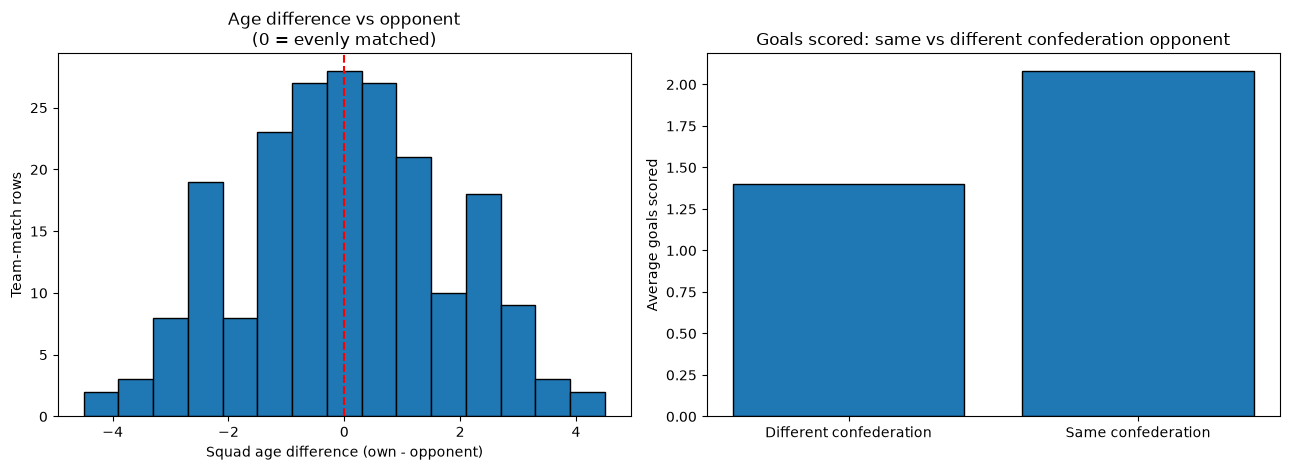

In [13]:
print(f"Matches against a team from the SAME confederation: {tm['Same_Confederation'].sum()} of {len(tm)} rows")
print(f"\nSquad_Age_Diff summary (this team's age minus the opponent's):")
print(tm["Squad_Age_Diff"].describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].hist(tm["Squad_Age_Diff"], bins=15, edgecolor="black")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_xlabel("Squad age difference (own - opponent)")
axes[0].set_ylabel("Team-match rows")
axes[0].set_title("Age difference vs opponent\n(0 = evenly matched)")

same_conf = tm.groupby("Same_Confederation")["Goals_For"].mean()
axes[1].bar(["Different confederation", "Same confederation"], same_conf.values, edgecolor="black")
axes[1].set_ylabel("Average goals scored")
axes[1].set_title("Goals scored: same vs different confederation opponent")

plt.tight_layout()
plt.savefig(FIGURES / "abhi_context_charts.png", dpi=150)
plt.show()

In [14]:
out_cols = ["Match_ID", "Team", "Home_Country_Advantage", "Squad_Age",
            "Opp_Squad_Age", "Squad_Age_Diff", "Confederation",
            "Opp_Confederation", "Same_Confederation"]
out = tm[out_cols].sort_values(["Match_ID", "Team"]).reset_index(drop=True)
out.round(4).to_csv(PROCESSED / "features_context_opponent.csv", index=False)
print(f"Saved {len(out)} rows -> data/clean/features_context_opponent.csv")
out.head(6)

Saved 208 rows -> data/clean/features_context_opponent.csv


,Match_ID,Team,Home_Country_Advantage,Squad_Age,Opp_Squad_Age,Squad_Age_Diff,Confederation,Opp_Confederation,Same_Confederation
0,1,Mexico,1,27.6,26.7,0.9,CONCACAF,CAF,0
1,1,South Africa,0,26.7,27.6,-0.9,CAF,CONCACAF,0
2,2,Czechia,0,27.8,28.2,-0.4,UEFA,AFC,0
3,2,Korea Republic,0,28.2,27.8,0.4,AFC,UEFA,0
4,3,Bosnia-Herz,0,26.6,26.9,-0.3,UEFA,CONCACAF,0
5,3,Canada,1,26.9,26.6,0.3,CONCACAF,UEFA,0


## Findings

- Only 13 of 208 team-match rows (about 6%) had a genuine host-country advantage — Mexico, Canada and
  the USA playing specifically inside their own country. The rest of their matches (e.g. Canada's games
  in US stadiums) correctly scored 0.
- Only 24 of 208 rows (about 12%) were matches between two teams from the same confederation, so
  Same_Confederation is a fairly rare signal, worth noting as a limitation.
- Squad age differences ranged from -4.5 to +4.5 years, centred almost exactly at 0, meaning most
  matchups were between reasonably similar-aged squads.